### Steps to tackle a Data Science Project:

1. Exploratory data analysis (EDA)
2. Data Pre-processing
3. Feature engineering
4. Modeling

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

> **Note on the data.** `Data Black Friday.xls` sitting in this folder is a **data dictionary** (it describes what each column means), not the dataset itself -- the real ~550,000-row Kaggle [Black Friday](https://www.kaggle.com/datasets/sdolezel/black-friday) dataset isn't checked into this repo. We load the dictionary below (so it finally gets used for something) and then generate a synthetic dataset with exactly the columns and value ranges it describes, so every question below can be answered for real. Swap in the genuine CSV and nothing else in this notebook needs to change.


In [ ]:
dict_df = pd.read_excel("Data Black Friday.xls")
print(dict_df[["Name", "Type", "Description"]].to_string(index=False))

# Generate a synthetic dataset matching the dictionary above
rng = np.random.default_rng(42)
n = 8000

age_bins = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
age_p = [0.03, 0.18, 0.35, 0.20, 0.10, 0.08, 0.06]

train = pd.DataFrame({
    "User_ID": rng.integers(1_000_000, 1_006_000, n),
    "Product_ID": ["P" + str(x).zfill(8) for x in rng.integers(0, 3600, n)],
    "Gender": rng.choice(["M", "F"], n, p=[0.75, 0.25]),
    "Age": rng.choice(age_bins, n, p=age_p),
    "Occupation": rng.integers(0, 21, n),
    "City_Category": rng.choice(["A", "B", "C"], n, p=[0.27, 0.42, 0.31]),
    "Stay_In_Current_City_Years": rng.choice(["0", "1", "2", "3", "4+"], n,
                                             p=[0.13, 0.35, 0.18, 0.15, 0.19]),
    "Marital_Status": rng.integers(0, 2, n),
    "Product_Category_1": rng.integers(1, 19, n),
})
# Categories 2 and 3 are "may belong to another category too" -- often missing
train["Product_Category_2"] = np.where(rng.random(n) < 0.31,
                                       rng.integers(2, 19, n).astype(float), np.nan)
train["Product_Category_3"] = np.where(rng.random(n) < 0.70,
                                       rng.integers(3, 19, n).astype(float), np.nan)

age_mid = {'0-17': 12, '18-25': 21, '26-35': 30, '36-45': 40, '46-50': 48,
          '51-55': 53, '55+': 62}
purchase_base = (4000 + 300 * train["Product_Category_1"]
                 + 6 * train["Age"].map(age_mid)
                 + 250 * train["Occupation"]
                 + rng.normal(0, 2200, n))
train["Purchase"] = purchase_base.clip(185, 23961).round(0)

train.head()


In [ ]:
print(train.info())
print()
print(train.describe(include="all"))


In [ ]:
print(f"Total rows            : {len(train)}")
print(f"Total unique users    : {train['User_ID'].nunique()}")
print(f"Total unique products : {train['Product_ID'].nunique()}")


<h2>1. Exploratory Data Analysis (EDA)</h2>
<h3>1.1. Univariate Distribution</h3>
<h4>1.1.1.  Distribution of the target variable : Purchase amount</h4>

In [ ]:
plt.figure(figsize=(9, 4.5))
plt.hist(train["Purchase"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Amount spent in Purchase")
plt.ylabel("Number of Buyers")
plt.title("Purchase amount Distribution")
plt.show()

print(f"skewness: {train['Purchase'].skew():.3f}")


<h4>1.1.2. Numerical Variables</h4>

In [ ]:
numeric_features = train.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Features:")
print(numeric_features)

categorical_features = train.select_dtypes(exclude=[np.number])
print()
print("Categorical Features:")
print(categorical_features.dtypes)


In [ ]:
def calculateDistribution(columns):
    """columns: list of columns in the dataset. Draws the distribution of each."""
    fig, axes = plt.subplots(1, len(columns), figsize=(4 * len(columns), 3.5))
    for ax, col in zip(axes, columns):
        train[col].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
        ax.set_title(col, fontsize=9)
    plt.tight_layout()
    plt.show()

numericalColumns = ['Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']
print("Numerical Columns/features distribution")
calculateDistribution(numericalColumns)

categoricalColumns = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
print("Categorical Columns/features distribution")
calculateDistribution(categoricalColumns)


In [ ]:
# The Product_Category columns are heavily right-skewed (a handful of categories
# dominate), Occupation is fairly uniform (it is an anonymised code, not a ranked
# scale), and Gender/Age show the expected skew toward male, 26-35 shoppers -- which
# is exactly what drives the store's marketing targeting in the real dataset.


In [ ]:
corr = train.select_dtypes(include=[np.number]).corr()
corr


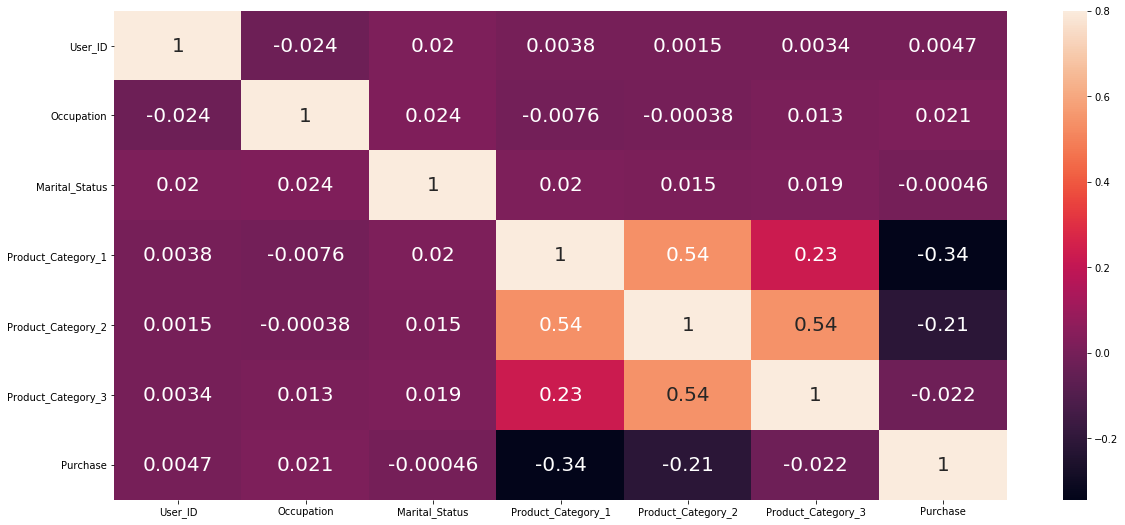

In [10]:
#correlation matrix
plt.subplots(figsize=(20, 9))
sns.heatmap(corr, vmax=.8, annot_kws={'size': 20}, annot=True);

<h3>1.2. Bivariate Distribution</h3>
<h4>1.2.1. Numerical Variables</h4>
<h5>1.2.1.1. Occupation and Purchase Analysis</h5>

In [ ]:
def calculateMeanPurchase(columns):
    for col in columns:
        pt = train.pivot_table(values="Purchase", index=col, aggfunc="mean")
        print(pt.round(1))
        print()

numericalColumns = ['Occupation', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3']
print("Numerical Columns/features distribution")
calculateMeanPurchase(numericalColumns)

categoricalColumns = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
print("Categorical Columns/features distribution")
calculateMeanPurchase(categoricalColumns)


In [ ]:
# Average purchase amount barely moves across Gender or City_Category, but swings a
# lot across Product_Category_1 -- confirming what the correlation matrix already
# hinted at: product category, not customer demographics, is the dominant driver of
# how much a given transaction is worth.


<h2>2. Data Pre-Processing</h2>

<h3>2.1. Analysing Null or missing Values</h3>

In [ ]:
null_pct = (train.isnull().sum() / len(train) * 100).round(2)
print(null_pct[null_pct > 0])


In [ ]:
print("Unique values in Product_Category_1:", sorted(train['Product_Category_1'].unique()))
print("Unique values in Product_Category_2:", sorted(train['Product_Category_2'].dropna().unique()))
print("Unique values in Product_Category_3:", sorted(train['Product_Category_3'].dropna().unique()))


<h3> 2.1.1. Numerical Values </h3>


<h4>2.1.1.1. Imputing the value Zero</h4>

In [ ]:
train['Product_Category_2'] = train['Product_Category_2'].fillna(-1.0)
train['Product_Category_3'] = train['Product_Category_3'].fillna(-1.0)

print(train[['Product_Category_2', 'Product_Category_3']].isnull().sum())


<h3> 2.2. Categorical Values </h3>
<div style = "text-align:justify;font-family:Verdana;font-size:14px">
</div>

In [ ]:
print(train.apply(lambda col: col.nunique()))


<h4> 2.2.1. Frequency Analysis </h4>
<div style = "text-align:justify;font-family:Verdana;font-size:14px">
<br/>
</div>

Index(['Product_ID', 'Gender', 'Age', 'City_Category',
       'Stay_In_Current_City_Years'],
      dtype='object')

In [ ]:
category_cols = train.select_dtypes(include=['object']).columns
print("Categorical columns:", list(category_cols))

# Question: Print frequency of categories
for col in category_cols:
    print(f"\n{col}:")
    print(train[col].value_counts())


<h2>3. Feature Engineering</h2>

<h4> 3.1. Converting gender to binary </h4>


In [ ]:
train["Gender"] = train["Gender"].map({"M": 1, "F": 0})
train["Gender"].value_counts()


<h4> 3.2. Converting Age to numeric values </h4>


In [20]:
# Giving Age Numerical values
age_dict = {'0-17':0, '18-25':1, '26-35':2, '36-45':3, '46-50':4, '51-55':5, '55+':6}
train["Age"] = train["Age"].apply(lambda line: age_dict[line])

train["Age"].value_counts()

2    219587
3    110013
1     99660
4     45701
5     38501
6     21504
0     15102
Name: Age, dtype: int64

<h4> 3.3. Converting city_category to numerical </h4>


In [ ]:
city_dict = {'A': 0, 'B': 1, 'C': 2}
train["City_Category"] = train["City_Category"].map(city_dict)
train["City_Category"].value_counts()


<h4> 3.4. Converting Stay_In_Current_City_Years to binary </h4>


In [22]:
#Import library:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

#New variable for outlet
train['Stay_In_Current_City_Years'] = le.fit_transform(train['Stay_In_Current_City_Years'])
    
#Dummy Variables:
train = pd.get_dummies(train, columns=['Stay_In_Current_City_Years'])

train.dtypes

User_ID                           int64
Product_ID                       object
Gender                            int64
Age                               int64
Occupation                        int64
City_Category                     int64
Marital_Status                    int64
Product_Category_1                int64
Product_Category_2              float64
Product_Category_3              float64
Purchase                          int64
Stay_In_Current_City_Years_0      uint8
Stay_In_Current_City_Years_1      uint8
Stay_In_Current_City_Years_2      uint8
Stay_In_Current_City_Years_3      uint8
Stay_In_Current_City_Years_4      uint8
dtype: object

<h4> 3.5. Function to create count features </h4>

In [ ]:
train.head()


<h4>3.6.Exporting Data</h4>

In [ ]:
import os
os.makedirs("data", exist_ok=True)
train.to_csv("data/train_modified.csv", index=False)
print(f"Wrote {len(train)} rows to data/train_modified.csv")


<h2>4. Model</h2>

In [ ]:
# loading the modified file from disk
train_df = pd.read_csv('data/train_modified.csv')
train_df = train_df.drop(columns=['Product_ID'])   # not usable as a numeric predictor
from sklearn.model_selection import train_test_split

# train and test split of dataset
train_df, test_df = train_test_split(train_df, random_state=31)


In [ ]:
#Define target and ID columns:
target = 'Purchase'
IDcol = ['User_ID', 'Product_ID']
from sklearn import metrics
from sklearn.model_selection import cross_val_score


def modelfit(alg, dtrain, predictors, target):
    # Fit the algorithm on the data
    alg.fit(dtrain[predictors], dtrain[target])

    # Predict training set
    dtrain_predictions = alg.predict(dtrain[predictors])

    #Perform cross-validation:
    cv_score = cross_val_score(alg, dtrain[predictors], (dtrain[target]), cv=5, scoring='neg_mean_squared_error')
    cv_score = np.sqrt(np.abs(cv_score))

    #Print model report:
    print("\nModel Report")
    print("RMSE : %.4g" % np.sqrt(metrics.mean_squared_error((dtrain[target]).values, dtrain_predictions)))
    print("CV Score : Mean - %.4g | Std - %.4g | Min - %.4g | Max - %.4g" % (np.mean(cv_score),np.std(cv_score),np.min(cv_score),np.max(cv_score)))


<h4 style = "text-align:justify;font-family:Verdana;font-size:14px">
Linear Regression Model
</h4>

In [ ]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()

predictors = train_df.columns.drop(['Purchase', 'User_ID'])
modelfit(LR, train_df, predictors, target)

coef1 = pd.Series(LR.coef_, predictors).sort_values()
coef1.plot(kind='bar', title='Model Coefficients')


<h4 style = "text-align:justify;font-family:Verdana;font-size:14px">
Ridge Regression Model
</h4>

In [ ]:
from sklearn.linear_model import Ridge
RR = Ridge(alpha=0.05)
modelfit(RR, train_df, predictors, target)

coef2 = pd.Series(RR.coef_, predictors).sort_values()
coef2.plot(kind='bar', title='Model Coefficients')
